
## Part 1 – Data Understanding

- Explore the dataset.
- Identify the data types.
- Produce summary statistics.
- Explain what each column represents.

In [ ]:
#install the libries
!pip install pandas
!pip install matplotlib
!pip install numpy

In [218]:
#load and import the libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#load the data
data = pd.read_csv('data/Ecommerce_Orders.csv')
data.head() #load the first 5 rows of data
data.shape
data.info() #identify the data types
data.describe(include = "all") #show the data summary statistics 
data.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1010 non-null   str    
 1   Customer_ID     1010 non-null   str    
 2   Order_Date      1010 non-null   str    
 3   Region          1010 non-null   str    
 4   Category        1010 non-null   str    
 5   Product         982 non-null    str    
 6   Sales           1010 non-null   float64
 7   Cost            1010 non-null   float64
 8   Discount        1010 non-null   int64  
 9   Shipping_Days   1010 non-null   int64  
 10  Customer_Age    1010 non-null   int64  
 11  Payment_Method  1010 non-null   str    
 12  Returned        1010 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 102.7 KB


,Order_ID,Customer_ID,Order_Date,Region,Category,Product,Sales,Cost,Discount,Shipping_Days,Customer_Age,Payment_Method,Returned
0,O00001,C1114,2025-11-06,East,Furniture,Desk,1161.76,1037.63,10,2,45,Card,No
1,O00002,C1186,2025-10-04,North,Office,Pen,1835.74,1581.68,25,1,48,Card,No
2,O00003,C1090,2025-07-21,South,Furniture,Chair,701.06,309.03,50,8,49,Cash,Yes
3,O00004,C1161,2025-12-13,North,Electronics,Laptop,518.03,332.40,40,10,24,Card,Yes
4,O00005,C1103,2025-11-28,South,Furniture,Desk,298.70,275.11,30,9,150,Bank Transfer,Yes
5,O00006,C1037,2025-10-30,North,Electronics,Headphones,1894.03,1443.89,10,8,63,PayPal,Yes
6,O00007,C1092,2025-03-01,West,Furniture,Chair,1249.16,903.99,5,7,38,Bank Transfer,Yes
7,O00008,C1111,2025-11-27,East,Electronics,Laptop,1184.11,763.70,25,4,43,PayPal,Yes
8,O00009,C1026,2025-09-29,East,Electronics,Headphones,1391.00,768.96,5,1,43,Bank Transfer,No
9,O00010,C1077,2025-03-01,South,Office,Pen,1352.65,1046.06,15,10,67,Cash,No


## Dataset Columns

The dataset contains **1,010 rows** and **13 columns**. Each row represents a single customer order placed with the company.

- **Order_ID:** A unique identifier assigned to each order.
- **Customer_ID:** A unique identifier assigned to each customer. A customer may place multiple orders.
- **Order_Date:** The date on which the customer placed the order.
- **Region:** The geographic region associated with the order or customer.
- **Category:** The category to which the purchased product belongs (e.g., Electronics, Furniture, Office).
- **Product:** The name of the product purchased by the customer.
- **Sales:** The total revenue generated from the order (the amount paid by the customer).
- **Cost:** The cost incurred by the company to provide the product in the order.
- **Discount:** The discount applied to the order, expressed as a percentage or value.
- **Shipping_Days:** The number of days taken to ship or deliver the order.
- **Customer_Age:** The age of the customer in years.
- **Payment_Method:** The payment method used by the customer to complete the purchase.
- **Returned:** Indicates whether the customer returned the purchased product (`Yes` or `No`).

## Part 2 – Data Quality Assessment

Identify and document:

- Missing values
- Duplicate records
- Incorrect data types
- Impossible values
- Outliers
- Inconsistent formatting
- Any other data quality issues you notice

Then clean the dataset appropriately.


In [219]:
data.isna().sum() #check for missing values
#there are 28 missing values in the product category

data.duplicated().sum()
#there are 10 duplicates values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        1010 non-null   str    
 1   Customer_ID     1010 non-null   str    
 2   Order_Date      1010 non-null   str    
 3   Region          1010 non-null   str    
 4   Category        1010 non-null   str    
 5   Product         982 non-null    str    
 6   Sales           1010 non-null   float64
 7   Cost            1010 non-null   float64
 8   Discount        1010 non-null   int64  
 9   Shipping_Days   1010 non-null   int64  
 10  Customer_Age    1010 non-null   int64  
 11  Payment_Method  1010 non-null   str    
 12  Returned        1010 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 102.7 KB


In [220]:
#CONVERT THE DATE COLUMN TOA DATE FORMAT.
data['Order_Date'] = pd.to_datetime(data['Order_Date'], format = "mixed")
display(data['Order_Date'])

data.info()
data.head()

0      2025-11-06
1      2025-10-04
2      2025-07-21
3      2025-12-13
4      2025-11-28
          ...    
1005   2025-05-27
1006   2025-05-28
1007   2025-11-03
1008   2025-08-14
1009   2025-05-05
Name: Order_Date, Length: 1010, dtype: datetime64[us]

<class 'pandas.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1010 non-null   str           
 1   Customer_ID     1010 non-null   str           
 2   Order_Date      1010 non-null   datetime64[us]
 3   Region          1010 non-null   str           
 4   Category        1010 non-null   str           
 5   Product         982 non-null    str           
 6   Sales           1010 non-null   float64       
 7   Cost            1010 non-null   float64       
 8   Discount        1010 non-null   int64         
 9   Shipping_Days   1010 non-null   int64         
 10  Customer_Age    1010 non-null   int64         
 11  Payment_Method  1010 non-null   str           
 12  Returned        1010 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(7)
memory usage: 102.7 KB


,Order_ID,Customer_ID,Order_Date,Region,Category,Product,Sales,Cost,Discount,Shipping_Days,Customer_Age,Payment_Method,Returned
0,O00001,C1114,2025-11-06,East,Furniture,Desk,1161.76,1037.63,10,2,45,Card,No
1,O00002,C1186,2025-10-04,North,Office,Pen,1835.74,1581.68,25,1,48,Card,No
2,O00003,C1090,2025-07-21,South,Furniture,Chair,701.06,309.03,50,8,49,Cash,Yes
3,O00004,C1161,2025-12-13,North,Electronics,Laptop,518.03,332.40,40,10,24,Card,Yes
4,O00005,C1103,2025-11-28,South,Furniture,Desk,298.70,275.11,30,9,150,Bank Transfer,Yes


In [221]:
#CHECK EACH COLUMNS TO ENUSRE EACH INPUT IS UNIQUE

data['Returned'].unique()
data['Region'].unique()
data['Product'].unique()
data['Payment_Method'].unique()
data['Category'].unique()
data['Customer_ID'].unique()

#ALL COLUMNS ARE UNIQUE ONLY THE PRODUCT COLUMNS HAS NAN.

<StringArray>
['C1114', 'C1186', 'C1090', 'C1161', 'C1103', 'C1037', 'C1092', 'C1111',
 'C1026', 'C1077',
 ...
 'C1046', 'C1132', 'C1078', 'C1068', 'C1130', 'C1043', 'C1170', 'C1047',
 'C1101', 'C1176']
Length: 201, dtype: str

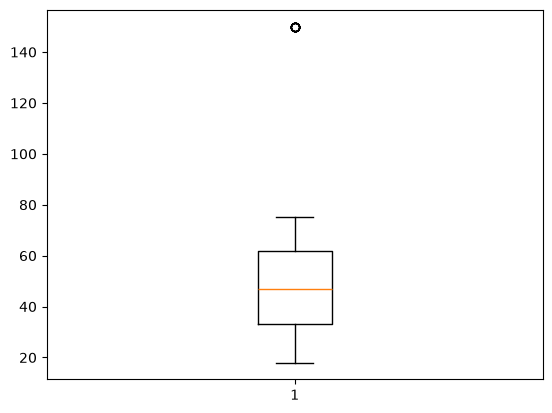

In [222]:
#create a boxplot to checkk for outliers
plt.boxplot(data['Customer_Age'])
plt.savefig('images/Customer_Age_outlier_detected.png', dpi=300, bbox_inches='tight')
plt.show()

#from the box blot we notioce that the age column has an outlier.

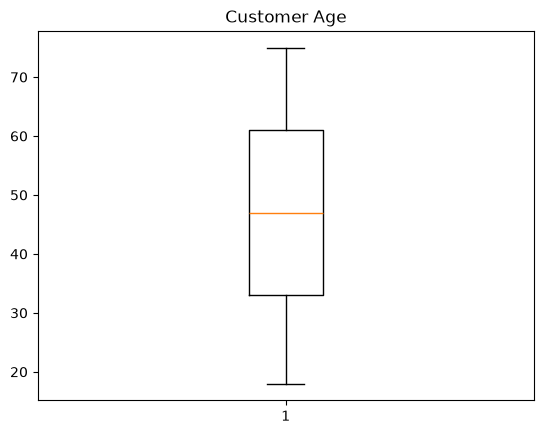

In [223]:
#from the box plot we see there there is an outlier in the age colunmn
data.describe(include='all')
#this shows the maximum of the age columns which give sus more insights to see that there is an age of 150 in the data set. we assume that was a mistake and we correct i to50
#here we locate everywhere in the data set where the age is 150 and we correct it to 50
data.loc[data['Customer_Age'] == 150, 'Customer_Age'] = 50 

#next we draw the boxplot again to confirm that there are noother putlierrs
plt.boxplot(data['Customer_Age'])
plt.title("Customer Age")
plt.savefig('images/customer_age_outlier_corrected.png', dpi=300, bbox_inches='tight')
plt.show()


In [224]:
#the product column has 28 missing values. we would fill it with unknown as we dont want to loose the data. remember we have their categories which also still tells a lot
data['Product'] = data['Product'].fillna("Unknown")
data

,Order_ID,Customer_ID,Order_Date,Region,Category,Product,Sales,Cost,Discount,Shipping_Days,Customer_Age,Payment_Method,Returned
0,O00001,C1114,2025-11-06,East,Furniture,Desk,1161.76,1037.63,10,2,45,Card,No
1,O00002,C1186,2025-10-04,North,Office,Pen,1835.74,1581.68,25,1,48,Card,No
2,O00003,C1090,2025-07-21,South,Furniture,Chair,701.06,309.03,50,8,49,Cash,Yes
3,O00004,C1161,2025-12-13,North,Electronics,Laptop,518.03,332.40,40,10,24,Card,Yes
4,O00005,C1103,2025-11-28,South,Furniture,Desk,298.70,275.11,30,9,50,Bank Transfer,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,O00014,C1029,2025-05-27,South,Office,Printer,469.47,396.48,15,5,24,Card,Yes
1006,O00015,C1189,2025-05-28,North,Electronics,Unknown,885.08,476.09,10,9,74,Cash,Yes
1007,O00016,C1119,2025-11-03,South,Office,Printer,1424.48,1023.33,10,3,27,Bank Transfer,Yes
1008,O00017,C1095,2025-08-14,East,Electronics,Headphones,672.80,625.29,0,3,72,Cash,No


In [225]:
#check for duplicates and remove them
data[data.duplicated(keep=False)]
data = data.drop_duplicates()
data[data.duplicated(keep=False)]

,Order_ID,Customer_ID,Order_Date,Region,Category,Product,Sales,Cost,Discount,Shipping_Days,Customer_Age,Payment_Method,Returned


In [226]:
#now lets do a final check to confirm that our data is clean
data.describe(include='all')
data.duplicated().sum()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1000 non-null   str           
 1   Customer_ID     1000 non-null   str           
 2   Order_Date      1000 non-null   datetime64[us]
 3   Region          1000 non-null   str           
 4   Category        1000 non-null   str           
 5   Product         1000 non-null   str           
 6   Sales           1000 non-null   float64       
 7   Cost            1000 non-null   float64       
 8   Discount        1000 non-null   int64         
 9   Shipping_Days   1000 non-null   int64         
 10  Customer_Age    1000 non-null   int64         
 11  Payment_Method  1000 non-null   str           
 12  Returned        1000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(7)
memory usage: 101.7 KB


## Part 3 – Exploratory Data Analysis (EDA)

Answer questions such as:

- Which region generated the highest sales?
- Which region generated the highest profit?
- Which product category sells the most?
- Which products generate the highest revenue?
- What is the average shipping time?
- Which payment method is used most often?
- Which age group spends the most?
- Which products are returned most frequently?
- Does a higher discount appear to increase sales?
- Are there any seasonal sales trends?


In [227]:
#Which region generated the highest sales?

sales_region = data.groupby('Region')['Sales'].sum()
print('Region with the highest sales:', sales_region.idxmax())
print('Total sales:', sales_region.max())

Region with the highest sales: West
Total sales: 254049.44


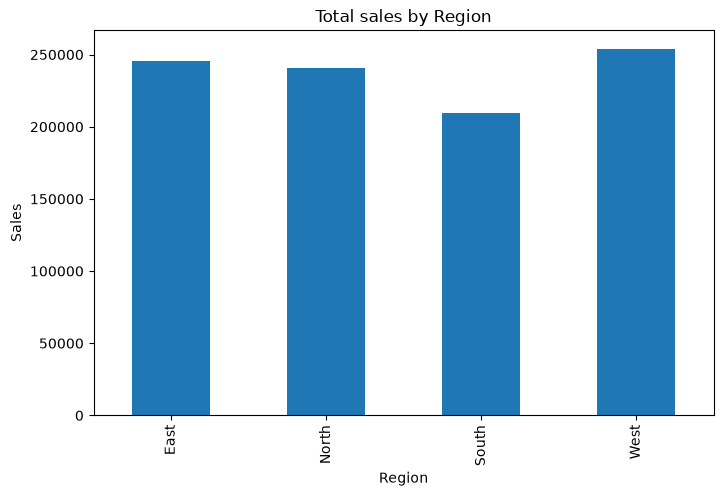

In [228]:
#create a bar shart to show this as a visualisation
plt.figure(figsize = (8,5))
sales_region.plot(kind = 'bar')
plt.title('Total sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.savefig('images/region_sales.png', dpi=300, bbox_inches='tight')
plt.show()


In [229]:
#Which region generated the highest profit?
#first we have to create a new profit column whihc would be the sales - cost

data['Profit'] = data['Sales'] - data['Cost']
data.head(6)
data.describe(include = 'all')

#now we have the prodit column, next w egroup regions by prodit

profit_region = data.groupby('Region')['Profit'].sum()
print('Region with the highest profit', profit_region.idxmax())
print("Highest total profit", profit_region.max())

Region with the highest profit West
Highest total profit 75762.14


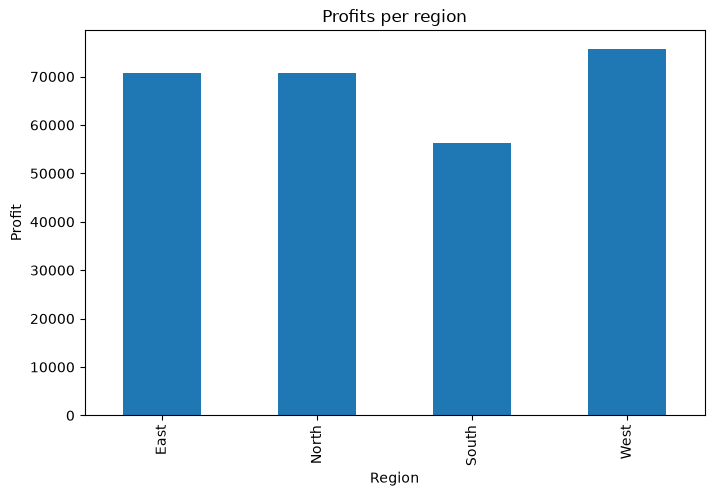

In [230]:
#Draw a bar chart to show the visualization of the region with the highest profit
plt.figure(figsize = (8,5))
profit_region.plot(kind = 'bar')
plt.title('Profits per region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.savefig('images/Highest_profit_region.png', dpi=300, bbox_inches='tight')
plt.show()


Product category that sells the most is: Electronics
Highest sales per category: 339418.16


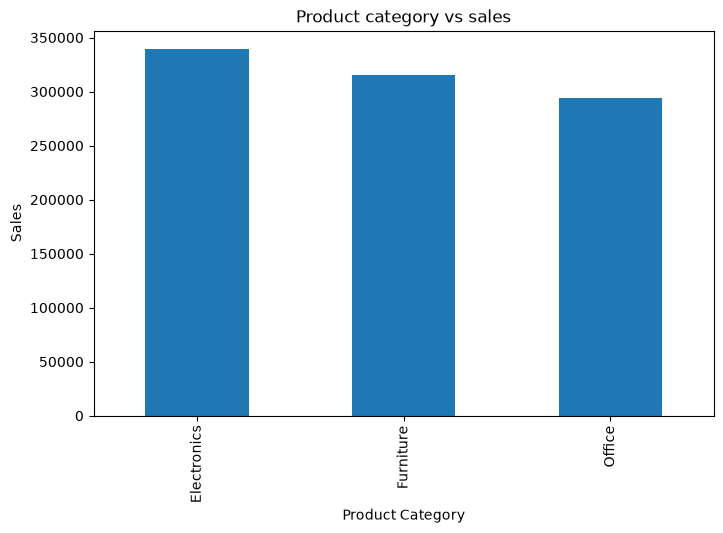

In [231]:
#Which product category sells the most?
#so we group category by sales

sales_category = data.groupby('Category')['Sales'].sum()
print('Product category that sells the most is:', sales_category.idxmax())
print('Highest sales per category:', sales_category.max())

plt.figure(figsize = (8,5))
sales_category.plot(kind = 'bar')
plt.title('Product category vs sales')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.savefig('images/Most_Sold_product_category.png', dpi=300, bbox_inches='tight')
plt.show()


Product that sells the most is: Headphones
Highest sales per product: 119415.66


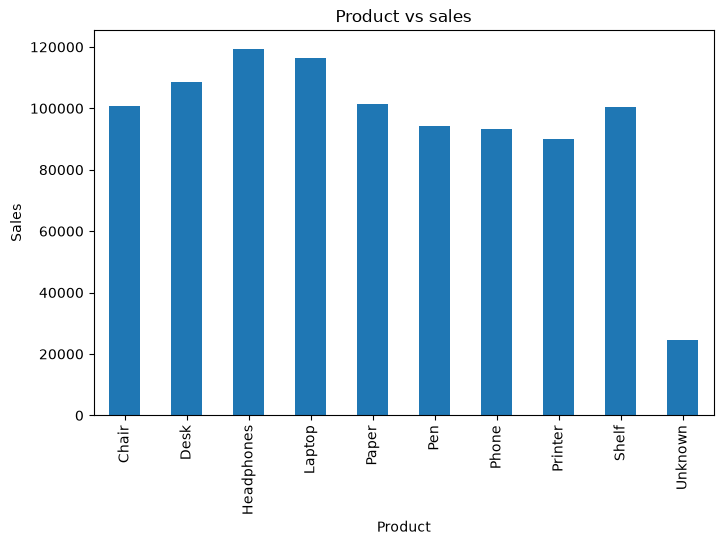

In [232]:
# Which products generate the highest revenue?

sales_product = data.groupby('Product')['Sales'].sum()
print('Product that sells the most is:', sales_product.idxmax())
print('Highest sales per product:', sales_product.max())

plt.figure(figsize = (8,5))
sales_product.plot(kind = 'bar')
plt.title('Product vs sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.savefig('images/Most_Sold_Products.png', dpi=300, bbox_inches='tight')
plt.show()

In [233]:
#What is the average shipping time?
average_shipping_time = round(data['Shipping_Days'].mean(), 2)
print('The average shipping time is:', average_shipping_time, 'days')

The average shipping time is: 5.55 days


In [235]:
#Which payment method is used most often?
#FIND THE MODEOF PAYMENT METHOD

Mode_paymentMethod = data['Payment_Method'].mode()[0]
print('The payment method used often is:',Mode_paymentMethod)


The payment method used often is: Card


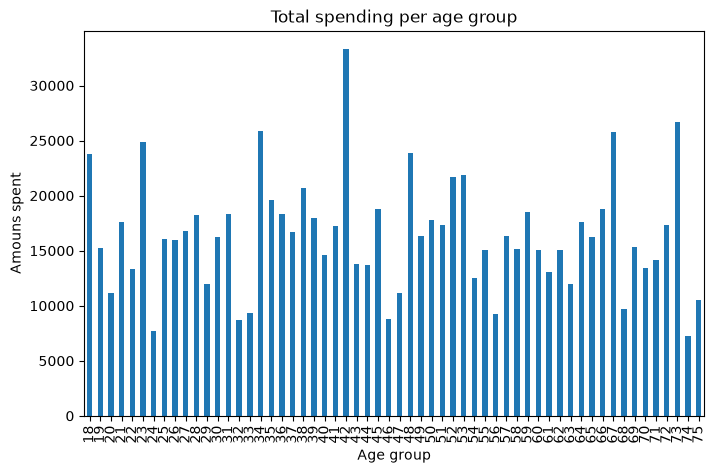

Age group that spends the most is: 42
Total amount spent: 33300.68


In [236]:
#Which age group spends the most?
data.head()
age_mostspend = data.groupby('Customer_Age')['Sales'].sum()

plt.figure(figsize = (8,5))
age_mostspend.plot(kind = 'bar')
plt.title('Total spending per age group')
plt.xlabel('Age group')
plt.ylabel('Amouns spent')
plt.savefig('images/Total_Spending_Per_Age.png', dpi=300, bbox_inches='tight')
plt.show()

print('Age group that spends the most is:', age_mostspend.idxmax())
print('Total amount spent:', age_mostspend.max())

Product
Laptop        7493.10
Chair         6402.77
Desk          5719.04
Phone         4035.31
Pen           3674.11
Shelf         2664.61
Paper         1986.88
Headphones     817.40
Unknown        507.46
Name: Sales, dtype: float64


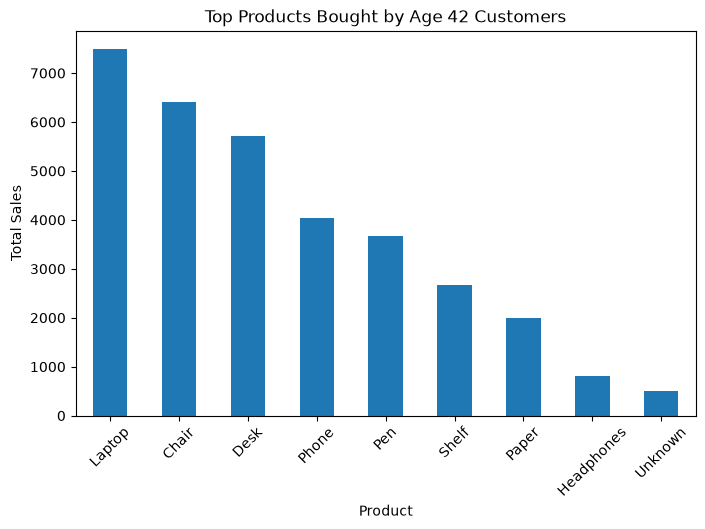

In [237]:
#going further to check what people of age 42 buy most often
age_42_data = data[data['Customer_Age'] == 42]
age_42_products = age_42_data.groupby('Product')['Sales'].sum().sort_values(ascending=False)

print(age_42_products.head(10))


plt.figure(figsize=(8,5))
age_42_products.head(10).plot(kind='bar')
plt.title('Top Products Bought by Age 42 Customers')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.savefig('images/Products_purchased_Age42.png', dpi=300, bbox_inches='tight')
plt.show()


Product
Headphones    65
Chair         62
Phone         56
Desk          53
Printer       52
Laptop        51
Pen           50
Paper         49
Shelf         42
Unknown        9
Name: count, dtype: int64


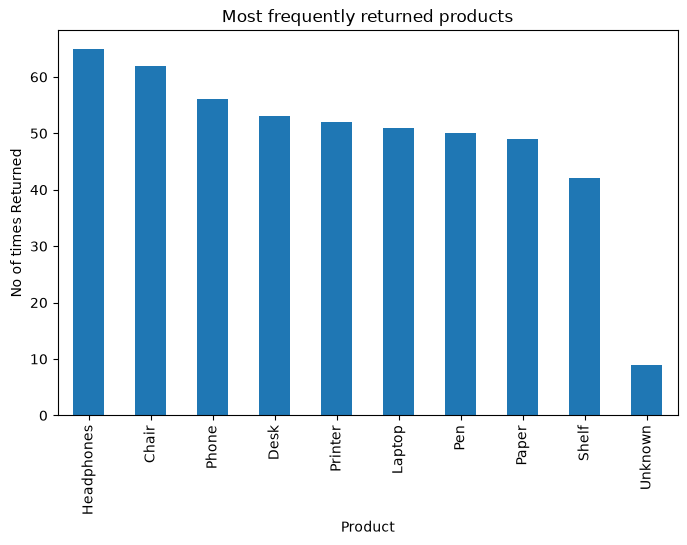

In [238]:
# Which products are returned most frequently?
returned_data = data[data['Returned'] == 'Yes']
returned_data.count()

products_returned = returned_data['Product'].value_counts()
print(products_returned)

plt.figure(figsize = (8,5))
plt.title('Most frequently returned products')
plt.ylabel('No of times Returned')
plt.xlabel('Products Returned')
products_returned.plot(kind = 'bar')
plt.savefig('images/Returned_products.png', dpi=300, bbox_inches='tight')
plt.show()


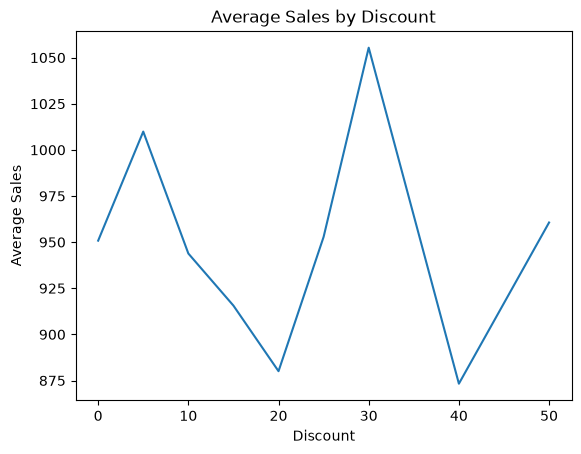

In [239]:
#Does a higher discount appear to increase sales?
discount_sales = data.groupby('Discount')['Sales'].mean()

discount_sales.plot(kind='line')
plt.title('Average Sales by Discount')
plt.xlabel('Discount')
plt.ylabel('Average Sales')
plt.savefig('images/average_sales_discount.png', dpi=300, bbox_inches='tight')
plt.show()

#from this we can see that it doesnt neccessarily appear to increase sales because the there is no direct trend that shows that the higher the discoun tthe higher the sales

In [240]:
data[data['Sales'] < 0] 
#during the analysis i noticed the sames column has negative values whihc brough tup some questions 
#were they incorrectly written or calculated?  At first i though they were returned items but after looking at the data we can see that they were not all returned items.
#Another assumption could be that the company made a loss on these sales because even the profit values are all negative numbers 

,Order_ID,Customer_ID,Order_Date,Region,Category,Product,Sales,Cost,Discount,Shipping_Days,Customer_Age,Payment_Method,Returned,Profit
22,O00023,C1174,2025-07-23,South,Electronics,Phone,-440.03,340.12,25,8,46,PayPal,No,-780.15
31,O00032,C1114,2025-08-26,South,Office,Printer,-1853.32,1143.07,20,8,60,Card,Yes,-2996.39
56,O00057,C1116,2025-04-06,West,Electronics,Phone,-1474.02,844.87,5,6,24,PayPal,No,-2318.89
73,O00074,C1055,2025-07-31,West,Furniture,Chair,-338.03,238.39,0,6,60,Card,No,-576.42
142,O00143,C1114,2025-09-01,South,Electronics,Phone,-227.36,167.53,0,9,53,Cash,No,-394.89
146,O00147,C1175,2025-01-27,South,Furniture,Shelf,-663.27,479.14,40,7,21,Card,No,-1142.41
267,O00268,C1024,2025-12-28,West,Office,Printer,-340.31,223.23,0,10,68,Bank Transfer,Yes,-563.54
374,O00375,C1149,2025-01-07,North,Office,Printer,-818.34,404.54,40,10,29,Card,Yes,-1222.88
393,O00394,C1001,2025-03-22,South,Electronics,Headphones,-742.04,360.44,10,4,68,PayPal,No,-1102.48
442,O00443,C1082,2025-03-06,South,Office,Pen,-1999.58,1813.72,50,5,75,Bank Transfer,Yes,-3813.30


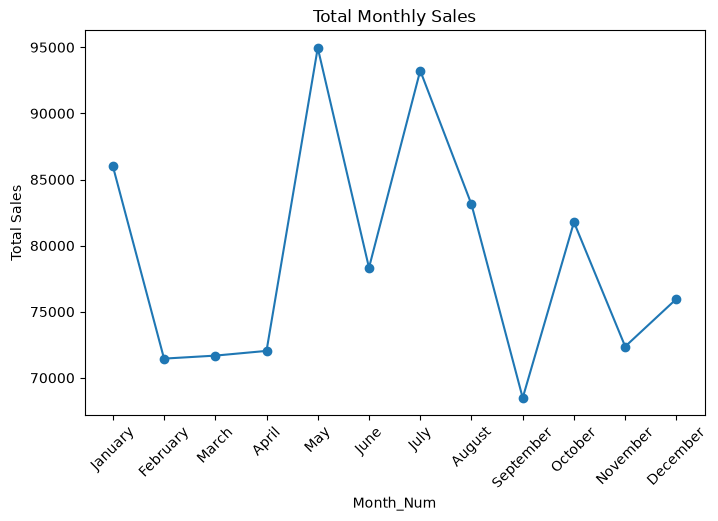

In [241]:
#Are there any seasonal sales trends?
# create month column
data['Month'] = data['Order_Date'].dt.month_name()

# set correct month order
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# convert Month to ordered categorical
data['Month_Num'] = data['Order_Date'].dt.month
monthly_sales = data.groupby('Month_Num')['Sales'].sum().sort_index()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.xticks(range(1,13), month_order, rotation=45)
plt.title('Total Monthly Sales')
plt.ylabel('Total Sales')
plt.savefig('images/monthly_sales.png', dpi=300, bbox_inches='tight')
plt.show()

Monthly sales varied throughout the year, indicating fluctuations in customer demand. Sales peaked in May and July, while September recorded the lowest sales. Although the data suggests possible seasonal patterns, one year of data is insufficient to confirm true seasonality. Further investigation into promotions, inventory levels, and marketing campaigns during high- and low-performing months could help explain these trends.

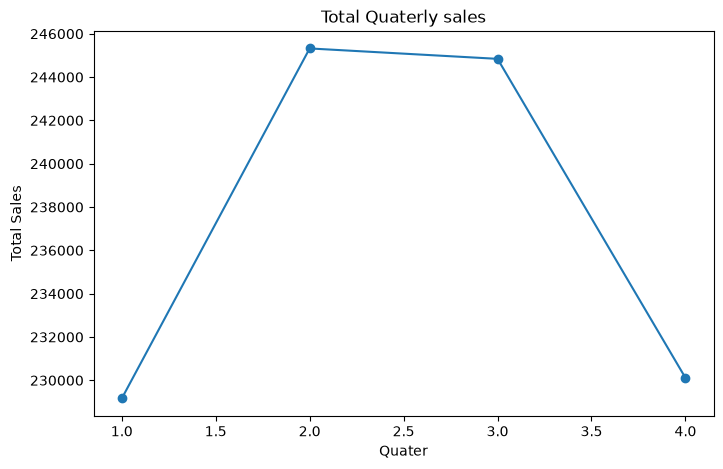

In [242]:

data['Quarter'] = data['Order_Date'].dt.quarter
quarter = data.groupby('Quarter')['Sales'].sum()

plt.figure(figsize = (8,5))
quarter.plot(kind='line', marker = 'o')
plt.title('Total Quaterly sales')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.savefig('images/quarterly_sales.png', dpi=300, bbox_inches='tight')
plt.show()